# Model Demo (Single Image)
Pick one image in the first code cell and run all available model checkpoints with minimal inference code.

In [2]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import torch
from PIL import Image
from torchvision import transforms

from MIREIA.config import Config
from MIREIA.perception import (
    DepthAnythingV2Estimator,
    RaftOpticalFlowEstimator,
    Sam2DashboardSegmenter,
    YoloObstacleDetector,
    create_environment_classifier_predictor,
    create_streaming_predictor,
    load_road_segmentation_model,
)

# Pick one image and rerun the notebook.
IMAGE_PATH = Path(r"T:\TFG\MIREIA\scenarios\02D_CloudyNoon_Town04_LowVol\dataset\images\rgb_013100.png")
# Optional explicit second frame for RAFT. Keep None to auto-pick the next numbered frame.
RAFT_IMAGE2_PATH = Path(r"T:\TFG\MIREIA\scenarios\02D_CloudyNoon_Town04_LowVol\dataset\images\rgb_013105.png")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

CHECKPOINTS = {
    "climate": Path(Config.PATH_TO_MODELS) / "environment_multitask_checkpoint.pt",
    "e2e": Path(Config.PATH_TO_MODELS) / "e2e_risk_checkpoint.pt",
    "road_seg": Path(Config.PATH_TO_MODELS) / "road_segmentation_multitask_checkpoint.pt",
    "yolo": Path(Config.PATH_TO_MODELS) / "yolo11s.pt",
    "depth": Path(Config.PATH_TO_MODELS) / "depth_anything_v2_vits.pth",
    "sam2": Path(Config.PATH_TO_MODELS) / "sam2.1_hiera_small.pt",
    "raft": Path(Config.PATH_TO_MODELS) / "raft" / "raft-kitti.pth",
}

if not IMAGE_PATH.is_file():
    raise FileNotFoundError(f"Image not found: {IMAGE_PATH}")


def _resolve_raft_pair(image_path: Path, explicit_second: Path | None) -> Path:
    if explicit_second is not None:
        if not explicit_second.is_file():
            raise FileNotFoundError(f"RAFT second image not found: {explicit_second}")
        return explicit_second

    match = re.match(r"^(.*?)(\d+)$", image_path.stem)
    if match:
        prefix, digits = match.groups()
        candidate = image_path.with_name(
            f"{prefix}{int(digits) + 1:0{len(digits)}d}{image_path.suffix}"
        )
        if candidate.is_file():
            return candidate

    return image_path


IMAGE2_PATH = _resolve_raft_pair(
    IMAGE_PATH,
    Path(RAFT_IMAGE2_PATH) if RAFT_IMAGE2_PATH else None,
)

with Image.open(IMAGE_PATH) as _img:
    IMAGE_RGB = _img.convert("RGB")
with Image.open(IMAGE2_PATH) as _img2:
    IMAGE2_RGB = _img2.convert("RGB")

if IMAGE_RGB.size != IMAGE2_RGB.size:
    raise ValueError(
        "RAFT image pair must have the same size. "
        f"Got {IMAGE_RGB.size} and {IMAGE2_RGB.size}"
    )

IMAGE_NP = np.asarray(IMAGE_RGB)

print(f"Image 1: {IMAGE_PATH}")
print(f"Image 2: {IMAGE2_PATH}")
if IMAGE2_PATH == IMAGE_PATH:
    print("[raft] Using the same frame twice; flow should be near zero.")
for name, path in CHECKPOINTS.items():
    if not path.is_file():
        print(f"[missing checkpoint] {name}: {path}")

Image 1: T:\TFG\MIREIA\scenarios\02D_CloudyNoon_Town04_LowVol\dataset\images\rgb_013100.png
Image 2: T:\TFG\MIREIA\scenarios\02D_CloudyNoon_Town04_LowVol\dataset\images\rgb_013105.png


In [3]:
def _disk_structure(radius: int = 3) -> np.ndarray:
    yy, xx = np.ogrid[-radius : radius + 1, -radius : radius + 1]
    return (yy * yy + xx * xx) <= (radius * radius)


def _binary_dilate(mask: np.ndarray, radius: int = 3) -> np.ndarray:
    mask_bool = np.asarray(mask, dtype=bool)
    if mask_bool.size == 0:
        return mask_bool

    structure = _disk_structure(radius=radius)

    try:
        from scipy.ndimage import binary_dilation

        return binary_dilation(mask_bool, structure=structure)
    except Exception:
        # Fallback: explicit dilation by OR-ing all active kernel offsets.
        pad_y, pad_x = radius, radius
        padded = np.pad(
            mask_bool,
            ((pad_y, pad_y), (pad_x, pad_x)),
            mode="constant",
            constant_values=False,
        )

        height, width = mask_bool.shape
        dilated = np.zeros((height, width), dtype=bool)
        ys, xs = np.nonzero(structure)
        for yk, xk in zip(ys, xs):
            dilated |= padded[yk : yk + height, xk : xk + width]

        return dilated


def _largest_connected_component(mask: np.ndarray) -> np.ndarray:
    mask_bool = np.asarray(mask, dtype=bool)
    if mask_bool.size == 0 or not mask_bool.any():
        return np.zeros_like(mask_bool, dtype=bool)

    try:
        from scipy.ndimage import label

        labels, num_labels = label(mask_bool, structure=np.ones((3, 3), dtype=np.uint8))
        if num_labels == 0:
            return np.zeros_like(mask_bool, dtype=bool)

        counts = np.bincount(labels.ravel())
        counts[0] = 0
        largest_label = int(np.argmax(counts))
        return labels == largest_label
    except Exception:
        height, width = mask_bool.shape
        visited = np.zeros_like(mask_bool, dtype=bool)
        neighbors = [
            (-1, -1),
            (-1, 0),
            (-1, 1),
            (0, -1),
            (0, 1),
            (1, -1),
            (1, 0),
            (1, 1),
        ]

        best_component: list[tuple[int, int]] = []

        for y in range(height):
            for x in range(width):
                if not mask_bool[y, x] or visited[y, x]:
                    continue

                stack = [(y, x)]
                visited[y, x] = True
                component: list[tuple[int, int]] = []

                while stack:
                    cy, cx = stack.pop()
                    component.append((cy, cx))

                    for dy, dx in neighbors:
                        ny, nx = cy + dy, cx + dx
                        if ny < 0 or ny >= height or nx < 0 or nx >= width:
                            continue
                        if visited[ny, nx] or not mask_bool[ny, nx]:
                            continue
                        visited[ny, nx] = True
                        stack.append((ny, nx))

                if len(component) > len(best_component):
                    best_component = component

        out = np.zeros_like(mask_bool, dtype=bool)
        for py, px in best_component:
            out[py, px] = True
        return out


def _postprocess_road_mask(mask: np.ndarray, dilation_radius: int = 3) -> np.ndarray:
    dilated = _binary_dilate(mask, radius=dilation_radius)
    return _largest_connected_component(dilated)


climate_prediction = None
risk_prediction = None
lane_mask = None
road_mask = None
seg_threshold = 0.5
yolo_detections = []
yolo_counts = {}
depth_prediction = None
depth_colored = None
sam2_result = None
raft_prediction = None

if CHECKPOINTS["climate"].is_file():
    try:
        climate_predictor = create_environment_classifier_predictor(
            checkpoint_path=str(CHECKPOINTS["climate"]),
            device=DEVICE,
        )
        climate_prediction = climate_predictor.predict_from_image_path(str(IMAGE_PATH))
    except Exception as exc:
        print(f"Climate inference failed: {exc}")

if CHECKPOINTS["e2e"].is_file():
    try:
        streaming_predictor = create_streaming_predictor(
            checkpoint_path=str(CHECKPOINTS["e2e"]),
            device=DEVICE,
        )
        for _ in range(streaming_predictor.temporal_config.sequence_len):
            risk_prediction = streaming_predictor.predict_from_image_path(str(IMAGE_PATH))
    except Exception as exc:
        print(f"E2E inference failed: {exc}")

if CHECKPOINTS["road_seg"].is_file():
    try:
        seg_result = load_road_segmentation_model(
            checkpoint_path=str(CHECKPOINTS["road_seg"]),
            device=DEVICE,
        )
        seg_model = seg_result["model"].to(DEVICE).eval()
        seg_h, seg_w = tuple(seg_result.get("image_size", (256, 256)))
        seg_threshold = float(seg_result.get("pred_threshold", 0.5))
        seg_transform = transforms.Compose(
            [
                transforms.Resize((int(seg_h), int(seg_w))),
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=(0.485, 0.456, 0.406),
                    std=(0.229, 0.224, 0.225),
                ),
            ]
        )
        seg_tensor = seg_transform(IMAGE_RGB).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            lane_logits, road_logits = seg_model(seg_tensor)
        lane_mask = torch.sigmoid(lane_logits)[0, 0].cpu().numpy() > seg_threshold
        road_mask_raw = torch.sigmoid(road_logits)[0, 0].cpu().numpy() > seg_threshold
        road_mask = _postprocess_road_mask(road_mask_raw, dilation_radius=3)
    except Exception as exc:
        print(f"Road segmentation inference failed: {exc}")

if CHECKPOINTS["yolo"].is_file():
    try:
        yolo_detector = YoloObstacleDetector(
            checkpoint_path=CHECKPOINTS["yolo"],
            confidence_threshold=0.25,
            iou_threshold=0.45,
            target_classes=(
                "person",
                "bicycle",
                "car",
                "motorcycle",
                "bus",
                "truck",
                "train",
                "traffic light",
            ),
        )
        yolo_detections = yolo_detector.detect(source=IMAGE_RGB, max_detections=100)
        yolo_counts = yolo_detector.detection_counts(yolo_detections)
    except Exception as exc:
        print(f"YOLO inference failed: {exc}")

if CHECKPOINTS["depth"].is_file():
    try:
        depth_estimator = DepthAnythingV2Estimator(
            checkpoint_path=CHECKPOINTS["depth"],
            encoder="vits",
            input_size=518,
        )
        depth_prediction = depth_estimator.predict(IMAGE_RGB)
        depth_colored = depth_prediction.colorize(colormap="magma")
    except Exception as exc:
        print(f"Depth inference failed: {exc}")

if CHECKPOINTS["sam2"].is_file():
    try:
        sam2_segmenter = Sam2DashboardSegmenter(
            checkpoint_path=CHECKPOINTS["sam2"],
            model_cfg="configs/sam2.1/sam2.1_hiera_s.yaml",
            device=DEVICE,
        )
        sam2_result = sam2_segmenter.create_dash_bb(
            source=IMAGE_RGB,
            instruction="Detect dashboard and car hood from the ego vehicle.",
            min_mask_area_ratio=0.001,
        )
    except Exception as exc:
        print(f"SAM2 inference failed: {exc}")

if CHECKPOINTS["raft"].is_file():
    try:
        raft_estimator = RaftOpticalFlowEstimator(
            checkpoint_path=CHECKPOINTS["raft"],
            device=DEVICE,
            small=False,
            mixed_precision=DEVICE.startswith("cuda"),
            alternate_corr=False,
        )
        raft_prediction = raft_estimator.predict(
            source_first=IMAGE_RGB,
            source_second=IMAGE2_RGB,
            iters=20,
            pad_mode="kitti",
        )
    except Exception as exc:
        print(f"RAFT inference failed: {exc}")

print("Inference complete.")

t:\TFG\env\Lib\site-packages\torchvision\transforms\functional.py:154: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:209.)
  img = torch.from_numpy(pic.transpose((2, 0, 1))).contiguous()


Inference complete.


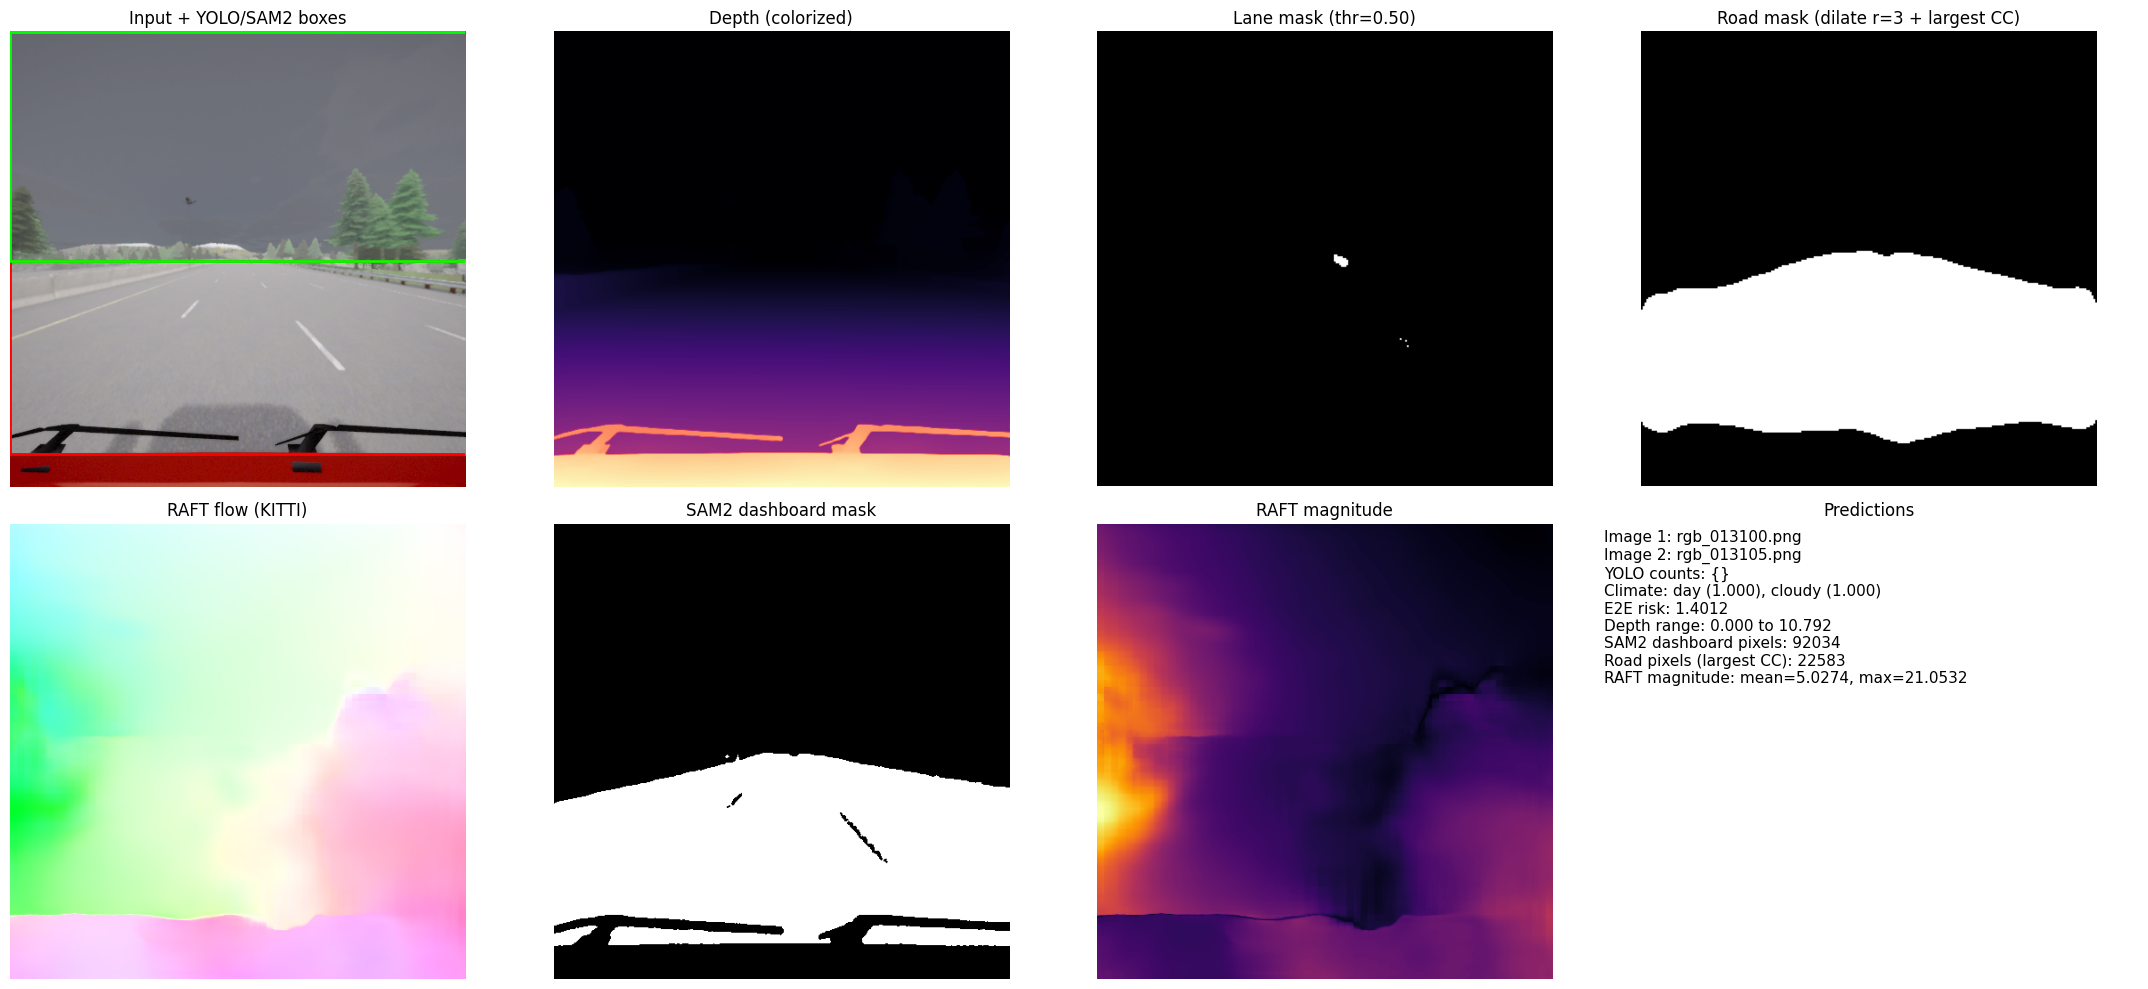

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))

axes[0, 0].imshow(IMAGE_RGB)
axes[0, 0].set_title("Input + YOLO/SAM2 boxes")
axes[0, 0].axis("off")
for det in yolo_detections:
    axes[0, 0].add_patch(
        patches.Rectangle(
            (det.x1, det.y1),
            det.width,
            det.height,
            linewidth=1.5,
            edgecolor="yellow",
            facecolor="none",
        )
    )
if sam2_result is not None and sam2_result.dashboard_bbox is not None:
    dash = sam2_result.dashboard_bbox
    axes[0, 0].add_patch(
        patches.Rectangle(
            (dash.x1, dash.y1),
            dash.width,
            dash.height,
            linewidth=2.0,
            edgecolor="red",
            facecolor="none",
        )
    )
if sam2_result is not None and sam2_result.inverse_bbox is not None:
    inv = sam2_result.inverse_bbox
    axes[0, 0].add_patch(
        patches.Rectangle(
            (inv.x1, inv.y1),
            inv.width,
            inv.height,
            linewidth=2.0,
            edgecolor="lime",
            facecolor="none",
        )
    )

if depth_colored is not None:
    axes[0, 1].imshow(depth_colored)
    axes[0, 1].set_title("Depth (colorized)")
else:
    axes[0, 1].text(0.5, 0.5, "Depth unavailable", ha="center", va="center")
    axes[0, 1].set_title("Depth")
axes[0, 1].axis("off")

if lane_mask is not None:
    axes[0, 2].imshow(lane_mask, cmap="gray")
    axes[0, 2].set_title(f"Lane mask (thr={seg_threshold:.2f})")
else:
    axes[0, 2].text(0.5, 0.5, "Lane mask unavailable", ha="center", va="center")
    axes[0, 2].set_title("Lane mask")
axes[0, 2].axis("off")

if road_mask is not None:
    axes[0, 3].imshow(road_mask, cmap="gray")
    axes[0, 3].set_title(f"Road mask (dilate r=3 + largest CC)")
else:
    axes[0, 3].text(0.5, 0.5, "Road mask unavailable", ha="center", va="center")
    axes[0, 3].set_title("Road mask")
axes[0, 3].axis("off")

if raft_prediction is not None:
    axes[1, 0].imshow(raft_prediction.colorize())
    axes[1, 0].set_title("RAFT flow (KITTI)")
else:
    axes[1, 0].text(0.5, 0.5, "RAFT unavailable", ha="center", va="center")
    axes[1, 0].set_title("RAFT flow")
axes[1, 0].axis("off")

if sam2_result is not None:
    axes[1, 1].imshow(sam2_result.dashboard_mask, cmap="gray")
    axes[1, 1].set_title("SAM2 dashboard mask")
else:
    axes[1, 1].text(0.5, 0.5, "SAM2 unavailable", ha="center", va="center")
    axes[1, 1].set_title("SAM2")
axes[1, 1].axis("off")

if raft_prediction is not None:
    axes[1, 2].imshow(raft_prediction.magnitude, cmap="inferno")
    axes[1, 2].set_title("RAFT magnitude")
else:
    axes[1, 2].text(0.5, 0.5, "RAFT magnitude unavailable", ha="center", va="center")
    axes[1, 2].set_title("RAFT magnitude")
axes[1, 2].axis("off")

summary = [
    f"Image 1: {IMAGE_PATH.name}",
    f"Image 2: {IMAGE2_PATH.name}",
    f"YOLO counts: {yolo_counts if yolo_counts else '{}'}",
]
if climate_prediction is not None:
    summary.append(
        "Climate: "
        f"{climate_prediction.day_night_label} ({climate_prediction.day_night_confidence:.3f}), "
        f"{climate_prediction.climate_label} ({climate_prediction.climate_confidence:.3f})"
    )
else:
    summary.append("Climate: unavailable")

if risk_prediction is not None and risk_prediction.ready and risk_prediction.latest_risk is not None:
    summary.append(f"E2E risk: {risk_prediction.latest_risk:.4f}")
else:
    summary.append("E2E risk: unavailable")

if depth_prediction is not None:
    summary.append(
        f"Depth range: {depth_prediction.min_depth:.3f} to {depth_prediction.max_depth:.3f}"
    )
if sam2_result is not None:
    summary.append(f"SAM2 dashboard pixels: {sam2_result.selected_area}")
if road_mask is not None:
    summary.append(f"Road pixels (largest CC): {int(np.sum(road_mask))}")
if raft_prediction is not None:
    summary.append(
        f"RAFT magnitude: mean={raft_prediction.mean_magnitude:.4f}, "
        f"max={raft_prediction.max_magnitude:.4f}"
    )

axes[1, 3].axis("off")
axes[1, 3].set_title("Predictions")
axes[1, 3].text(0.01, 0.99, "\n".join(summary), ha="left", va="top", fontsize=11)

plt.tight_layout()
plt.show()

## RAFT vs Phase Correlation (Global Ego-Motion)
This section compares RAFT with a lightweight CPU-friendly phase-correlation estimator.
The phase estimator returns a global shift `(bg_flow_x, bg_flow_y)` between two frames.

Phase correlation bg_flow: x=0.0166, y=-0.0622, strength=0.0644 (time=4.39 ms)
RAFT global bg_flow (median): x=-1.3975, y=1.4333, strength=2.0018 (reduction time=1.77 ms, model inference done in previous cell)


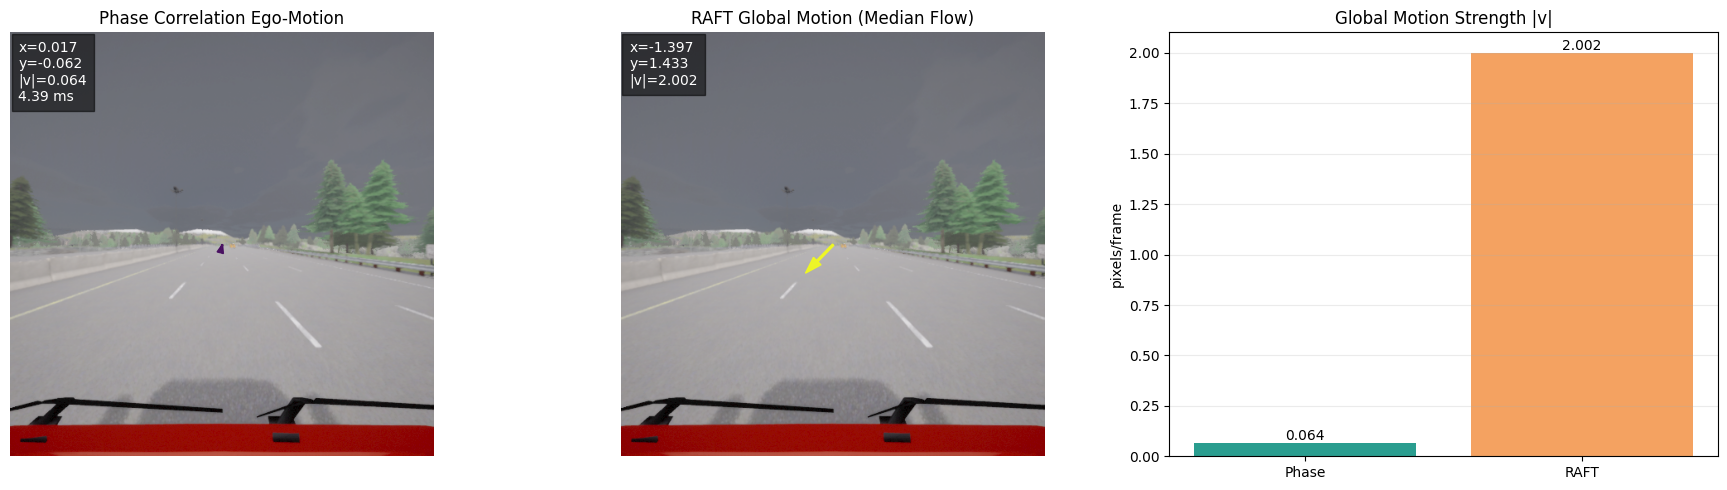

In [7]:
import time
import numpy as np
import matplotlib.pyplot as plt

from MIREIA.perception.flow import EgoMotionEstimator

frame1_np = np.asarray(IMAGE_RGB, dtype=np.uint8)
frame2_np = np.asarray(IMAGE2_RGB, dtype=np.uint8)

ego_motion_estimator = EgoMotionEstimator(crop_ratio=0.9)

t0 = time.perf_counter()
bg_flow_x, bg_flow_y = ego_motion_estimator.estimate_motion(frame1_np, frame2_np)
phase_time_ms = (time.perf_counter() - t0) * 1000.0
phase_strength = float(np.hypot(bg_flow_x, bg_flow_y))

raft_bg_flow_x = None
raft_bg_flow_y = None
raft_strength = None
if raft_prediction is not None:
    t1 = time.perf_counter()
    raft_bg_flow_x = float(np.median(raft_prediction.flow_xy[..., 0]))
    raft_bg_flow_y = float(np.median(raft_prediction.flow_xy[..., 1]))
    raft_strength = float(np.hypot(raft_bg_flow_x, raft_bg_flow_y))
    raft_reduce_time_ms = (time.perf_counter() - t1) * 1000.0
else:
    raft_reduce_time_ms = None

print(
    f"Phase correlation bg_flow: x={bg_flow_x:.4f}, y={bg_flow_y:.4f}, "
    f"strength={phase_strength:.4f} (time={phase_time_ms:.2f} ms)"
)
if raft_bg_flow_x is not None and raft_bg_flow_y is not None and raft_strength is not None:
    print(
        f"RAFT global bg_flow (median): x={raft_bg_flow_x:.4f}, y={raft_bg_flow_y:.4f}, "
        f"strength={raft_strength:.4f} "
        f"(reduction time={raft_reduce_time_ms:.2f} ms, model inference done in previous cell)"
    )
else:
    print("RAFT global bg_flow unavailable (run the RAFT inference cell/checkpoint first).")

h, w = frame1_np.shape[:2]
cx, cy = w / 2.0, h / 2.0
max_strength = max(1e-6, phase_strength, raft_strength or 0.0)

phase_ratio = min(1.0, phase_strength / max_strength)
phase_arrow_scale = 8.0 + 16.0 * phase_ratio
phase_line_width = max(1.0, min(h, w) * (0.0015 + 0.003 * phase_ratio))
phase_head_width = max(6.0, min(h, w) * (0.015 + 0.01 * phase_ratio))
phase_head_length = max(8.0, min(h, w) * (0.02 + 0.02 * phase_ratio))
phase_color = plt.cm.viridis(phase_ratio)

if raft_strength is not None:
    raft_ratio = min(1.0, raft_strength / max_strength)
    raft_arrow_scale = 8.0 + 16.0 * raft_ratio
    raft_line_width = max(1.0, min(h, w) * (0.0015 + 0.003 * raft_ratio))
    raft_head_width = max(6.0, min(h, w) * (0.015 + 0.01 * raft_ratio))
    raft_head_length = max(8.0, min(h, w) * (0.02 + 0.02 * raft_ratio))
    raft_color = plt.cm.plasma(raft_ratio)
else:
    raft_ratio = 0.0
    raft_arrow_scale = 8.0
    raft_line_width = max(1.0, min(h, w) * 0.0015)
    raft_head_width = max(6.0, min(h, w) * 0.015)
    raft_head_length = max(8.0, min(h, w) * 0.02)
    raft_color = "orange"

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(frame1_np)
axes[0].set_title("Phase Correlation Ego-Motion")
axes[0].axis("off")
axes[0].arrow(
    cx,
    cy,
    bg_flow_x * phase_arrow_scale,
    bg_flow_y * phase_arrow_scale,
    color=phase_color,
    width=phase_line_width,
    head_width=phase_head_width,
    head_length=phase_head_length,
    length_includes_head=True,
    alpha=0.95,
)
axes[0].text(
    0.02,
    0.98,
    f"x={bg_flow_x:.3f}\ny={bg_flow_y:.3f}\n|v|={phase_strength:.3f}\n{phase_time_ms:.2f} ms",
    transform=axes[0].transAxes,
    va="top",
    ha="left",
    color="white",
    bbox={"facecolor": "black", "alpha": 0.55, "pad": 5},
)

axes[1].imshow(frame1_np)
axes[1].set_title("RAFT Global Motion (Median Flow)")
axes[1].axis("off")
if raft_bg_flow_x is not None and raft_bg_flow_y is not None and raft_strength is not None:
    axes[1].arrow(
        cx,
        cy,
        raft_bg_flow_x * raft_arrow_scale,
        raft_bg_flow_y * raft_arrow_scale,
        color=raft_color,
        width=raft_line_width,
        head_width=raft_head_width,
        head_length=raft_head_length,
        length_includes_head=True,
        alpha=0.95,
    )
    axes[1].text(
        0.02,
        0.98,
        f"x={raft_bg_flow_x:.3f}\ny={raft_bg_flow_y:.3f}\n|v|={raft_strength:.3f}",
        transform=axes[1].transAxes,
        va="top",
        ha="left",
        color="white",
        bbox={"facecolor": "black", "alpha": 0.55, "pad": 5},
    )
else:
    axes[1].text(0.5, 0.5, "RAFT unavailable", ha="center", va="center")

labels = ["Phase"]
strength_values = [phase_strength]
if raft_strength is not None:
    labels.append("RAFT")
    strength_values.append(raft_strength)

bars = axes[2].bar(labels, strength_values, color=["#2a9d8f", "#f4a261"][: len(labels)])
axes[2].set_title("Global Motion Strength |v|")
axes[2].set_ylabel("pixels/frame")
axes[2].grid(axis="y", alpha=0.25)
for bar, val in zip(bars, strength_values):
    axes[2].text(
        bar.get_x() + bar.get_width() / 2.0,
        bar.get_height(),
        f"{val:.3f}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()